# Sanity Check - Step 02: Rename & Set Montage

Überprüft:
- Kanäle korrekt umbenannt (BioSemi → 10-20)
- Montage gesetzt
- Elektroden-Positionen vorhanden
- Kanal-Metadaten intakt

In [1]:
import os
import sys
from pathlib import Path

import mne
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

root = Path.cwd()
candidate_roots = [root, root.parent, root.parent.parent]
for candidate in candidate_roots:
    pipeline_dir = candidate / "eeg_pipeline"
    if pipeline_dir.exists() and str(pipeline_dir) not in sys.path:
        sys.path.insert(0, str(pipeline_dir))
    if candidate.exists() and str(candidate) not in sys.path:
        sys.path.insert(0, str(candidate))

try:
    from eeg_pipeline import config
except ModuleNotFoundError:
    import config

print("Setup erfolgreich")
print(f"QC directory: {config.QC_DIR}")

Setup erfolgreich
QC directory: c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\qc


In [2]:
# Manuelle Auswahl fuer diesen Notebook-Run
subject_id = "01"  # z.B. "02"
persons = ["P1", "P2"]  # oder nur ["P1"]
invalid = [p for p in persons if p not in {"P1", "P2"}]
if invalid:
    raise ValueError(f"Ungueltige Person(en): {invalid}. Erlaubt: P1,P2")
os.environ["EEG_SUBJECT"] = subject_id
os.environ["EEG_PERSONS"] = ",".join(persons)
print(f"Manuell gesetzt: EEG_SUBJECT={os.environ['EEG_SUBJECT']}, EEG_PERSONS={os.environ['EEG_PERSONS']}")

Manuell gesetzt: EEG_SUBJECT=01, EEG_PERSONS=P1,P2


## 1. Renamed+Montaged Files laden

In [3]:
subject_id = os.getenv("EEG_SUBJECT", config.SUBJECTS[0]).strip()
persons_env = os.getenv("EEG_PERSONS", "")
if persons_env.strip():
    persons = [p.strip().upper() for p in persons_env.split(",") if p.strip()]
else:
    persons = ["P1", "P2"]

valid_persons = {"P1", "P2"}
invalid = [p for p in persons if p not in valid_persons]
if invalid:
    raise ValueError(f"Ungültige Person(en): {invalid}. Erlaubt: P1,P2")

files = {}
for person in persons:
    path = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_renamed_montaged.fif"
    if path.exists():
        files[person] = mne.io.read_raw_fif(str(path), preload=False)
        print(f"✓ {person}: {path.name}")
    else:
        print(f"✗ {person}: File not found")

Opening raw data file c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_renamed_montaged.fif...


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29296\2011909280.py:17: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_renamed_montaged.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  files[person] = mne.io.read_raw_fif(str(path), preload=False)


    Range : 0 ... 733799 =      0.000 ...  3668.995 secs
Ready.
✓ P1: sub-01_P1_renamed_montaged.fif
Opening raw data file c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_renamed_montaged.fif...


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29296\2011909280.py:17: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_renamed_montaged.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  files[person] = mne.io.read_raw_fif(str(path), preload=False)


    Range : 0 ... 733799 =      0.000 ...  3668.995 secs
Ready.
✓ P2: sub-01_P2_renamed_montaged.fif


## 2. Channel Names Before Renaming (BioSemi)

In [4]:
for person in persons:
    path = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_split.fif"
    if not path.exists():
        print(f"✗ {person}: split file not found ({path.name})")
        continue
    raw_before = mne.io.read_raw_fif(str(path), preload=False, verbose=False)
    print(f"\n=== {person} — Channel Names Before Renaming ===")
    print(f"Total channels: {len(raw_before.ch_names)}")
    for i, ch in enumerate(raw_before.ch_names, 1):
        print(f"  {i:3d}. {ch}")

C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29296\1360098890.py:6: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_split.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_before = mne.io.read_raw_fif(str(path), preload=False, verbose=False)



=== P1 — Channel Names Before Renaming ===
Total channels: 72
    1. 2-A1
    2. 2-A2
    3. 2-A3
    4. 2-A4
    5. 2-A5
    6. 2-A6
    7. 2-A7
    8. 2-A8
    9. 2-A9
   10. 2-A10
   11. 2-A11
   12. 2-A12
   13. 2-A13
   14. 2-A14
   15. 2-A15
   16. 2-A16
   17. 2-A17
   18. 2-A18
   19. 2-A19
   20. 2-A20
   21. 2-A21
   22. 2-A22
   23. 2-A23
   24. 2-A24
   25. 2-A25
   26. 2-A26
   27. 2-A27
   28. 2-A28
   29. 2-A29
   30. 2-A30
   31. 2-A31
   32. 2-A32
   33. 2-B1
   34. 2-B2
   35. 2-B3
   36. 2-B4
   37. 2-B5
   38. 2-B6
   39. 2-B7
   40. 2-B8
   41. 2-B9
   42. 2-B10
   43. 2-B11
   44. 2-B12
   45. 2-B13
   46. 2-B14
   47. 2-B15
   48. 2-B16
   49. 2-B17
   50. 2-B18
   51. 2-B19
   52. 2-B20
   53. 2-B21
   54. 2-B22
   55. 2-B23
   56. 2-B24
   57. 2-B25
   58. 2-B26
   59. 2-B27
   60. 2-B28
   61. 2-B29
   62. 2-B30
   63. 2-B31
   64. 2-B32
   65. 2-GSR1
   66. 2-GSR2
   67. 2-Erg1
   68. 2-Erg2
   69. 2-Resp
   70. 2-Plet
   71. 2-Temp
   72. Status


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29296\1360098890.py:6: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_split.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_before = mne.io.read_raw_fif(str(path), preload=False, verbose=False)



=== P2 — Channel Names Before Renaming ===
Total channels: 72
    1. 1-A1
    2. 1-A2
    3. 1-A3
    4. 1-A4
    5. 1-A5
    6. 1-A6
    7. 1-A7
    8. 1-A8
    9. 1-A9
   10. 1-A10
   11. 1-A11
   12. 1-A12
   13. 1-A13
   14. 1-A14
   15. 1-A15
   16. 1-A16
   17. 1-A17
   18. 1-A18
   19. 1-A19
   20. 1-A20
   21. 1-A21
   22. 1-A22
   23. 1-A23
   24. 1-A24
   25. 1-A25
   26. 1-A26
   27. 1-A27
   28. 1-A28
   29. 1-A29
   30. 1-A30
   31. 1-A31
   32. 1-A32
   33. 1-B1
   34. 1-B2
   35. 1-B3
   36. 1-B4
   37. 1-B5
   38. 1-B6
   39. 1-B7
   40. 1-B8
   41. 1-B9
   42. 1-B10
   43. 1-B11
   44. 1-B12
   45. 1-B13
   46. 1-B14
   47. 1-B15
   48. 1-B16
   49. 1-B17
   50. 1-B18
   51. 1-B19
   52. 1-B20
   53. 1-B21
   54. 1-B22
   55. 1-B23
   56. 1-B24
   57. 1-B25
   58. 1-B26
   59. 1-B27
   60. 1-B28
   61. 1-B29
   62. 1-B30
   63. 1-B31
   64. 1-B32
   65. 1-GSR1
   66. 1-GSR2
   67. 1-Erg1
   68. 1-Erg2
   69. 1-Resp
   70. 1-Plet
   71. 1-Temp
   72. Status


## 3. EEG-Kanal Namen (10-20 Standard)

In [5]:
for person, raw in files.items():
    eeg_picks = mne.pick_types(raw.info, eeg=True)
    eeg_names = [raw.ch_names[i] for i in eeg_picks]
    
    print(f"\n=== {person} ===")
    print(f"EEG-Kanäle: {len(eeg_names)}")
    print(f"Erste 16 Kanäle:")
    for i, ch in enumerate(eeg_names[:16], 1):
        print(f"  {i:2d}. {ch}")
    
    # Check for standard 10-20
    standard_1020 = {"Fp1", "Fp2", "Fz", "F3", "F4", "Cz", "C3", "C4", "Pz", "P3", "P4", "Oz"}
    found = sum(1 for ch in eeg_names if ch in standard_1020)
    print(f"\nStandard 10-20 Kanäle gefunden: {found}/{len(eeg_names)}")


=== P1 ===
EEG-Kanäle: 64
Erste 16 Kanäle:
   1. Fp1
   2. AF7
   3. AF3
   4. F1
   5. F3
   6. F5
   7. F7
   8. FT7
   9. FC5
  10. FC3
  11. FC1
  12. C1
  13. C3
  14. C5
  15. T7
  16. TP7

Standard 10-20 Kanäle gefunden: 12/64

=== P2 ===
EEG-Kanäle: 64
Erste 16 Kanäle:
   1. Fp1
   2. AF7
   3. AF3
   4. F1
   5. F3
   6. F5
   7. F7
   8. FT7
   9. FC5
  10. FC3
  11. FC1
  12. C1
  13. C3
  14. C5
  15. T7
  16. TP7

Standard 10-20 Kanäle gefunden: 12/64


## 4. Montage & Elektrodenpositionen

In [6]:
for person, raw in files.items():
    print(f"\n{person}:")
    
    if raw.info.get('dig') is not None and len(raw.info['dig']) > 0:
        n_dig = len(raw.info['dig'])
        print(f"  ✓ Montage gesetzt: {n_dig} Digitalisierungspunkte")
    else:
        print(f"  ✗ Keine Elektrodenpositionen vorhanden")
    
    # Check for old prefixes
    prefix = config.PLAYER_PREFIX_MAP[person]
    old_count = sum(1 for ch in raw.ch_names if ch.startswith(prefix))
    if old_count == 0:
        print(f"  ✓ Alte Präfixe entfernt")
    else:
        print(f"  ⚠ {old_count} Kanäle haben noch Präfix '{prefix}'")


P1:
  ✓ Montage gesetzt: 67 Digitalisierungspunkte
  ⚠ 7 Kanäle haben noch Präfix '2-'

P2:
  ✓ Montage gesetzt: 67 Digitalisierungspunkte
  ⚠ 7 Kanäle haben noch Präfix '1-'


## 4. Visualisierung und Side-by-Side-Vergleich
Erzeugt 2D/3D-Sensorplots pro Person und vergleicht mit dem Originalbild.
Die Referenz-Positionen fuer den Vergleich werden wie im Originalskript direkt aus biosemi64.mat geladen (ohne zusaetzliches Rescaling).

✓ Original-Layout gefunden: c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\biosemiActive2_cap_64_layout_medium.jpg
✓ P1: 2D gespeichert -> sub-01_P1_montage_positions_2d_notebook.png
✓ P1: 3D gespeichert -> sub-01_P1_montage_positions_3d_notebook.png


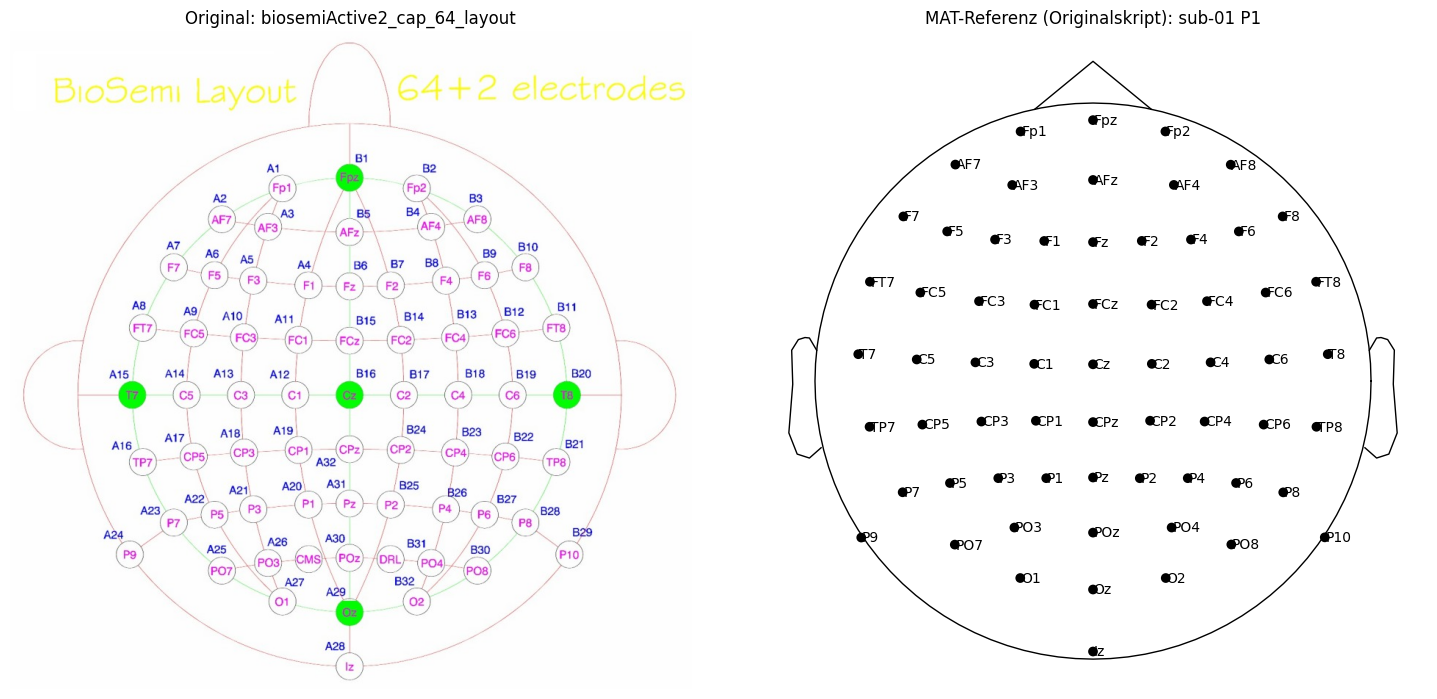

✓ P1: Side-by-Side gespeichert -> sub-01_P1_layout_comparison_side_by_side.png
✓ P2: 2D gespeichert -> sub-01_P2_montage_positions_2d_notebook.png
✓ P2: 3D gespeichert -> sub-01_P2_montage_positions_3d_notebook.png


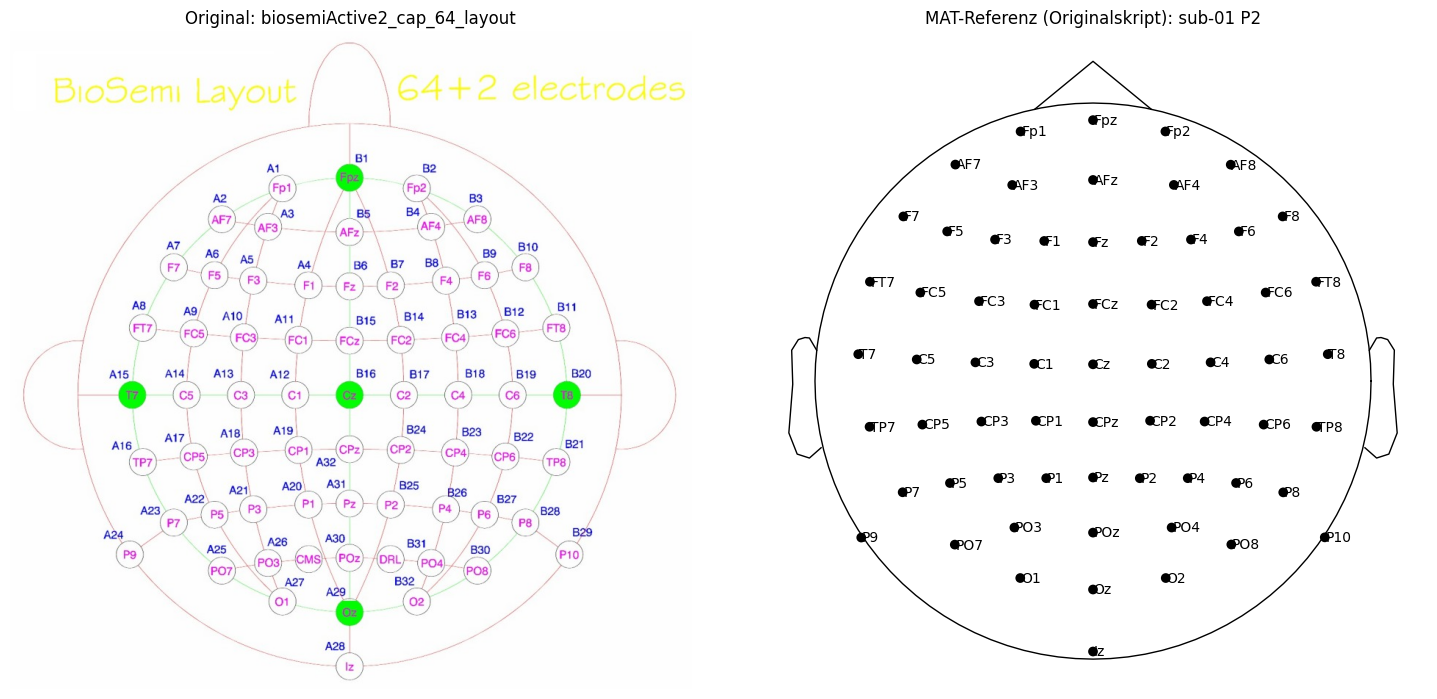

✓ P2: Side-by-Side gespeichert -> sub-01_P2_layout_comparison_side_by_side.png


In [7]:
from scipy.io import loadmat

config.QC_DIR.mkdir(parents=True, exist_ok=True)

original_layout_path = root / "biosemiActive2_cap_64_layout_medium.jpg"
if not original_layout_path.exists():
    original_layout_path = root.parent / "biosemiActive2_cap_64_layout_medium.jpg"

if original_layout_path.exists():
    original_img = mpimg.imread(original_layout_path)
    print(f"✓ Original-Layout gefunden: {original_layout_path}")
else:
    original_img = None
    print("⚠ Original-Layout nicht gefunden: biosemiActive2_cap_64_layout_medium.jpg")

labels = list(config.channel_labels.values())
mat = loadmat(str(config.BIOSEMI64_MAT_PATH))
if "biosemi64" not in mat:
    raise KeyError("Variable 'biosemi64' nicht in biosemi64.mat gefunden")

mat_xyz = np.asarray(mat["biosemi64"], dtype=float)
if mat_xyz.shape != (64, 3):
    raise ValueError(f"Erwartete Form (64, 3), erhalten: {mat_xyz.shape}")

mat_map = {lab: tuple(mat_xyz[i]) for i, lab in enumerate(labels)}
mat_montage = mne.channels.make_dig_montage(ch_pos=mat_map, coord_frame="head")

# Nur fuer die Darstellung: Kopfkreis groesser/tiefer wie im Originalbild.
# Sensorpositionen und Daten werden dadurch NICHT veraendert.
xy = mat_xyz[:, :2]
cx, cy = np.mean(xy, axis=0)
r95 = float(np.percentile(np.linalg.norm(xy - np.array([cx, cy]), axis=1), 95))
DISPLAY_RADIUS_SCALE = 1.18
DISPLAY_Y_SHIFT = -0.08 * r95
DISPLAY_SPHERE = (float(cx), float(cy + DISPLAY_Y_SHIFT), 0.0, float(r95 * DISPLAY_RADIUS_SCALE))

for person, raw in files.items():
    raw_eeg = raw.copy().pick("eeg")

    # A) Aktuelles gespeichertes Layout aus dem FIF (nur visuelle Sphere-Anpassung)
    fig2d = raw_eeg.plot_sensors(
        kind="topomap",
        show_names=True,
        sphere=DISPLAY_SPHERE,
        show=False,
    )
    fig2d.suptitle(f"sub-{subject_id} {person} EEG sensor layout (2D)")
    out2d = config.QC_DIR / f"sub-{subject_id}_{person}_montage_positions_2d_notebook.png"
    fig2d.savefig(out2d, dpi=200, bbox_inches="tight")
    plt.close(fig2d)
    print(f"✓ {person}: 2D gespeichert -> {out2d.name}")

    try:
        fig3d = raw_eeg.plot_sensors(kind="3d", show_names=False, show=False)
        fig3d.suptitle(f"sub-{subject_id} {person} EEG sensor layout (3D)")
        out3d = config.QC_DIR / f"sub-{subject_id}_{person}_montage_positions_3d_notebook.png"
        fig3d.savefig(out3d, dpi=200, bbox_inches="tight")
        plt.close(fig3d)
        print(f"✓ {person}: 3D gespeichert -> {out3d.name}")
    except Exception as exc:
        print(f"⚠ {person}: 3D-Plot konnte nicht gespeichert werden ({exc})")

    # B) Side-by-side: links Originalbild, rechts MAT-basierte Referenz
    if original_img is not None:
        fig_cmp, axes = plt.subplots(1, 2, figsize=(15, 7))
        axes[0].imshow(original_img)
        axes[0].set_title("Original: biosemiActive2_cap_64_layout")
        axes[0].axis("off")

        info_mat = mne.create_info(ch_names=labels, sfreq=raw.info["sfreq"], ch_types="eeg")
        info_mat.set_montage(mat_montage, on_missing="ignore")
        mne.viz.plot_sensors(
            info_mat,
            kind="topomap",
            ch_type="eeg",
            show_names=True,
            sphere=DISPLAY_SPHERE,
            axes=axes[1],
            show=False,
        )
        axes[1].set_title(f"MAT-Referenz (Originalskript): sub-{subject_id} {person}")

        fig_cmp.tight_layout()
        out_cmp = config.QC_DIR / f"sub-{subject_id}_{person}_layout_comparison_side_by_side.png"
        fig_cmp.savefig(out_cmp, dpi=200, bbox_inches="tight")
        plt.show()
        plt.close(fig_cmp)
        print(f"✓ {person}: Side-by-Side gespeichert -> {out_cmp.name}")

## 5. QC: Daten- und Koordinaten-Integritaet
Prueft automatisch, dass Rename+Montage die EEG-Signale nicht veraendert und dass die gesetzten Elektrodenpositionen den Werten aus biosemi64.mat entsprechen.

In [8]:
from scipy.io import loadmat
import numpy as np
import mne

subject_id = globals().get("subject_id", os.getenv("EEG_SUBJECT", config.SUBJECTS[0]).strip())
persons = globals().get("persons", ["P1", "P2"])
inv_channel_labels = {v: k for k, v in config.channel_labels.items()}

mat = loadmat(str(config.BIOSEMI64_MAT_PATH))
if "biosemi64" not in mat:
    raise KeyError("Variable 'biosemi64' nicht in biosemi64.mat gefunden")
mat_xyz = np.asarray(mat["biosemi64"], dtype=float)

print(f"QC fuer sub-{subject_id}")
for person in persons:
    path_before = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_split.fif"
    path_after = config.OUTPUT_DIR / f"sub-{subject_id}_{person}_renamed_montaged.fif"

    if not path_before.exists() or not path_after.exists():
        print(f"\n{person}: ⚠ Dateien fehlen ({path_before.name} oder {path_after.name})")
        continue

    raw_before = mne.io.read_raw_fif(str(path_before), preload=False, verbose=False)
    raw_after = mne.io.read_raw_fif(str(path_after), preload=False, verbose=False)

    # 1) Datenvergleich: Nach dem Renaming muss jedes Ziel-Label auf den korrekten Quellkanal zeigen.
    data_diffs = []
    checked_channels = []
    source_prefix = config.PLAYER_PREFIX_MAP[person]

    for ch_after in raw_after.ch_names:
        if ch_after not in inv_channel_labels:
            continue
        source_key = inv_channel_labels[ch_after]
        ch_before = f"{source_prefix}{source_key}"
        if ch_before not in raw_before.ch_names:
            continue

        after_ts = raw_after.get_data(picks=[ch_after])[0]
        before_ts = raw_before.get_data(picks=[ch_before])[0]
        data_diffs.append(float(np.max(np.abs(after_ts - before_ts))))
        checked_channels.append((ch_after, ch_before))

    # 2) Koordinatenvergleich: Montage im FIF gegen biosemi64.mat
    montage = raw_after.get_montage()
    ch_pos = montage.get_positions()["ch_pos"] if montage is not None else {}
    coord_diffs = []
    for idx, lab in enumerate(list(config.channel_labels.values())):
        if lab in ch_pos:
            coord_diffs.append(float(np.linalg.norm(np.asarray(ch_pos[lab]) - mat_xyz[idx])))

    max_data_diff = max(data_diffs) if data_diffs else np.nan
    max_coord_diff = max(coord_diffs) if coord_diffs else np.nan

    print(f"\n{person}:")
    print(f"  Gepruefte Kanalzuordnungen: {len(checked_channels)}")
    print(f"  Max |Signal-Differenz| vorher/nachher: {max_data_diff:.3e}")
    print(f"  Max |Koordinaten-Differenz| FIF vs MAT: {max_coord_diff:.3e}")

    if np.isfinite(max_data_diff) and max_data_diff < 1e-12:
        print("  ✓ Signale unveraendert durch Rename+Montage")
    else:
        print("  ⚠ Signaldifferenz > Toleranz, bitte Mapping pruefen")

    # 1e-6 ist ausreichend streng fuer Float-Rundung beim FIF I/O
    if np.isfinite(max_coord_diff) and max_coord_diff < 1e-6:
        print("  ✓ Koordinaten entsprechen direkt biosemi64.mat")
    else:
        print("  ⚠ Koordinatenabweichung > Toleranz, bitte Montage pruefen")

QC fuer sub-01


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29296\953579475.py:23: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_split.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_before = mne.io.read_raw_fif(str(path_before), preload=False, verbose=False)
C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29296\953579475.py:24: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P1_renamed_montaged.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_after = mne.io.read_raw_fif(str(path_after), preload=False, verbose=False)



P1:
  Gepruefte Kanalzuordnungen: 64
  Max |Signal-Differenz| vorher/nachher: 0.000e+00
  Max |Koordinaten-Differenz| FIF vs MAT: 3.541e-08
  ✓ Signale unveraendert durch Rename+Montage
  ✓ Koordinaten entsprechen direkt biosemi64.mat


C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29296\953579475.py:23: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_split.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_before = mne.io.read_raw_fif(str(path_before), preload=False, verbose=False)
C:\Users\BKALYON\AppData\Local\Temp\ipykernel_29296\953579475.py:24: RuntimeWarning: This filename (c:\Users\BKALYON\Bala_Sharks\eeg-bala-sharks\data\sub-01_P2_renamed_montaged.fif) does not conform to MNE naming conventions. All raw files should end with raw.fif, raw_sss.fif, raw_tsss.fif, _meg.fif, _eeg.fif, _ieeg.fif, raw.fif.gz, raw_sss.fif.gz, raw_tsss.fif.gz, _meg.fif.gz, _eeg.fif.gz or _ieeg.fif.gz
  raw_after = mne.io.read_raw_fif(str(path_after), preload=False, verbose=False)



P2:
  Gepruefte Kanalzuordnungen: 64
  Max |Signal-Differenz| vorher/nachher: 0.000e+00
  Max |Koordinaten-Differenz| FIF vs MAT: 3.541e-08
  ✓ Signale unveraendert durch Rename+Montage
  ✓ Koordinaten entsprechen direkt biosemi64.mat
